# 07. Baseline: TF-IDF + LogisticRegression

Мультиклассовая классификация бренда по тексту запроса.

Метрики: Accuracy, F1-macro/micro, confusion matrix.


In [1]:
import sys
from pathlib import Path
ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (8, 4)


In [2]:
import joblib
import pandas as pd
import pyarrow.parquet as pq
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, ConfusionMatrixDisplay

DATA = ROOT / 'файлы' / 'query_clicks.parquet'
MODELS = ROOT / 'models'
MODELS.mkdir(exist_ok=True)
FIG = ROOT / 'figures'
FIG.mkdir(exist_ok=True)


In [3]:
pf = pq.ParquetFile(DATA)
parts = []
seen = 0
for i in range(pf.num_row_groups):
    t = pf.read_row_group(i, columns=['toValidUTF8(query_text)', 'toValidUTF8(sku_brand_name)'])
    df = t.to_pandas()
    df.columns = ['query', 'brand']
    parts.append(df)
    seen += len(df)
    if seen >= 150000:
        break
df = pd.concat(parts, ignore_index=True)
df['query'] = df['query'].fillna('').astype(str).str.strip()
df['brand'] = df['brand'].fillna('').astype(str).str.strip()
df = df[(df['query'].str.len() >= 2) & (df['brand'].str.len() >= 2)].drop_duplicates('query')
top = {b for b, _ in Counter(df['brand']).most_common(80)}
df = df[df['brand'].isin(top)]
print(df.shape, 'classes', df['brand'].nunique())


(19556, 2) classes 80


In [4]:
Xtr, Xte, ytr, yte = train_test_split(
    df['query'], df['brand'], test_size=0.2, random_state=42, stratify=df['brand']
)
pipe = Pipeline([
    ('tfidf', TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4), min_df=2, max_features=50000)),
    ('clf', LogisticRegression(max_iter=200, solver='saga', n_jobs=-1)),
])
pipe.fit(Xtr, ytr)
pred = pipe.predict(Xte)
print('accuracy', (pred == yte).mean())
print('f1_macro', f1_score(yte, pred, average='macro'))
print('f1_micro', f1_score(yte, pred, average='micro'))
print(classification_report(yte, pred, zero_division=0)[:2000])
joblib.dump(pipe, MODELS / 'brand_clf.joblib')


C:\Users\kamau\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


accuracy 0.727760736196319
f1_macro 0.6680091698293771
f1_micro 0.727760736196319
                  precision    recall  f1-score   support

            ASUS       0.91      0.72      0.80        71
          ATLANT       0.81      0.68      0.74        19
            Acer       1.00      0.58      0.73        19
             Ami       0.44      0.27      0.33        15
           Apple       0.79      0.91      0.84       291
             BBK       1.00      0.54      0.70        13
           Ballu       1.00      0.50      0.67        14
          Baseus       0.64      0.62      0.63        40
            Beko       0.74      0.64      0.68        44
           Bosch       0.86      0.74      0.80        66
           Braun       0.92      0.77      0.84        30
          Brayer       0.86      0.24      0.38        25
           Candy       0.97      0.67      0.79        48
           Canon       0.94      0.80      0.86        20
         Carrera       0.84      0.67      0.74

['C:\\Users\\kamau\\Documents\\мвидео\\models\\brand_clf.joblib']

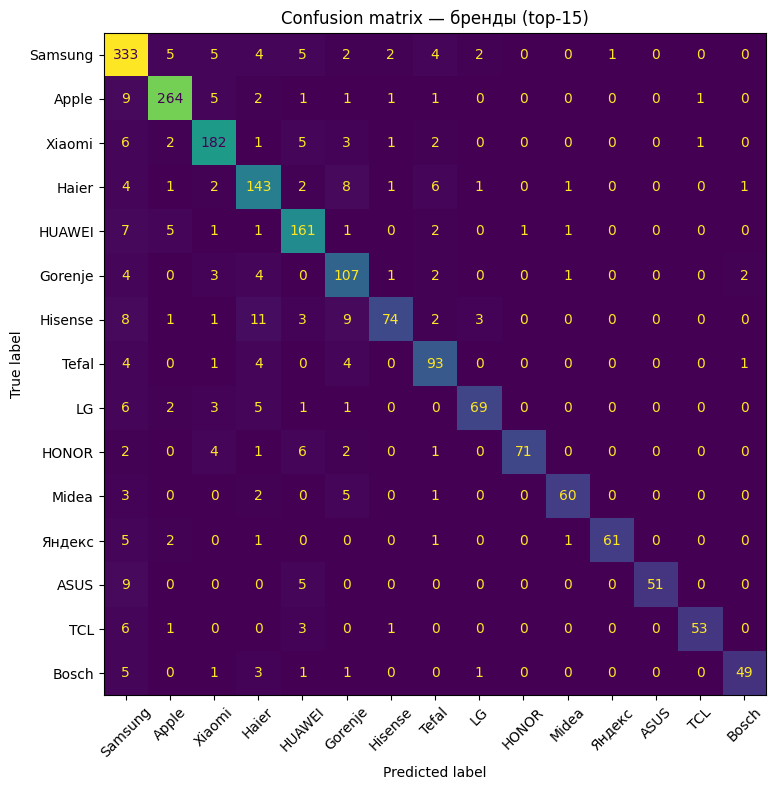

In [5]:
top15 = [b for b, _ in Counter(yte).most_common(15)]
mask = yte.isin(top15)
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    yte[mask], pred[mask], labels=top15, ax=ax, xticks_rotation=45, colorbar=False
)
ax.set_title('Confusion matrix — бренды (top-15)')
fig.tight_layout()
fig.savefig(FIG / '13_confusion_matrix.png', dpi=140)
plt.show()
